In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
# Read the data 
tables = ['hotels', 'daily_finance', 'bookings', 'customer_reviews', 'campaigns']

for table in tables:
    globals() ['df_'+table] = pd.read_excel('EDA_Project_02_Hotel_Operations.xlsx', sheet_name=table)

In [3]:
# Task 1 — Initial inspection
tables_info = {}
print(f"Table hotels has {df_hotels.shape[0]} rows and {df_hotels.shape[1]} columns")
print(f"Columns names are: {df_hotels.columns}")

Table hotels has 6 rows and 7 columns
Columns names are: Index(['hotel_id', 'hotel_name', 'city_id', 'category', 'rooms', 'opened_date', 'manager'], dtype='object')


In [4]:
# columns dtypes
df_hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hotel_id     6 non-null      int64         
 1   hotel_name   6 non-null      object        
 2   city_id      6 non-null      int64         
 3   category     6 non-null      object        
 4   rooms        6 non-null      int64         
 5   opened_date  6 non-null      datetime64[ns]
 6   manager      6 non-null      object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 468.0+ bytes


In [5]:
# Check missing values
df_hotels.isna().sum()

hotel_id       0
hotel_name     0
city_id        0
category       0
rooms          0
opened_date    0
manager        0
dtype: int64

In [6]:
# Check for duplicated 
df_hotels[df_hotels.duplicated(keep=False)]

,hotel_id,hotel_name,city_id,category,rooms,opened_date,manager


In [7]:
# shows first 5 rows 
df_hotels.head()

,hotel_id,hotel_name,city_id,category,rooms,opened_date,manager
0,101,Sofia Central,1,Business,180,2018-05-14,Anna Petrova
1,102,Sofia Airport,1,Business,220,2020-09-01,Ivan Georgiev
2,103,Varna Sea View,2,Resort,160,2017-06-20,Maria Dimitrova
3,104,Plovdiv Old Town,3,Boutique,95,2019-03-11,Petar Iliev
4,105,Burgas Marina,4,Resort,140,2021-07-05,Elena Nikolova


In [8]:
tables_info['hotels'] = {
    'rows': df_hotels.shape[0],
    'columns': df_hotels.shape[1],
    'columns_name': df_hotels.columns,
    'dtypes': df_hotels.dtypes,
    'missing_values': df_hotels.isna().sum(),
    'duplicated': df_hotels[df_hotels.duplicated()],
}

In [9]:
for k,v in tables_info['hotels'].items():
    print(k,": ",v)

rows :  6
columns :  7
columns_name :  Index(['hotel_id', 'hotel_name', 'city_id', 'category', 'rooms', 'opened_date', 'manager'], dtype='object')
dtypes :  hotel_id                int64
hotel_name             object
city_id                 int64
category               object
rooms                   int64
opened_date    datetime64[ns]
manager                object
dtype: object
missing_values :  hotel_id       0
hotel_name     0
city_id        0
category       0
rooms          0
opened_date    0
manager        0
dtype: int64
duplicated :  Empty DataFrame
Columns: [hotel_id, hotel_name, city_id, category, rooms, opened_date, manager]
Index: []


In [10]:
# initial inspection daily_finance
print(f"Table hotels has {df_daily_finance.shape[0]} rows and {df_daily_finance.shape[1]} columns.")
print(f"Daily_finance columns: \n {df_daily_finance.columns}")

Table hotels has 1082 rows and 9 columns.
Daily_finance columns: 
 Index(['date', 'hotel_id', 'revenue_gbp', 'room_revenue_gbp', 'food_revenue_gbp', 'operating_cost_gbp', 'occupancy_pct', 'rating', 'notes'], dtype='object')


In [11]:
#check dtypes in daily_finance
df_daily_finance.dtypes

date                  datetime64[ns]
hotel_id                       int64
revenue_gbp                  float64
room_revenue_gbp             float64
food_revenue_gbp             float64
operating_cost_gbp           float64
occupancy_pct                float64
rating                       float64
notes                         object
dtype: object

In [12]:
# Check for missing values 
df_daily_finance.isna().sum()

date                    0
hotel_id                0
revenue_gbp             1
room_revenue_gbp        0
food_revenue_gbp        0
operating_cost_gbp      1
occupancy_pct           0
rating                  0
notes                 871
dtype: int64

In [13]:
# Check for duplicates 
df_daily_finance[df_daily_finance.duplicated(keep=False)]

,date,hotel_id,revenue_gbp,room_revenue_gbp,food_revenue_gbp,operating_cost_gbp,occupancy_pct,rating,notes
120,2026-01-21,101,19038.99,14303.18,4735.82,13082.35,77.7,4.04,NaN
121,2026-01-21,102,24811.14,18377.66,6433.48,17920.84,79.1,4.29,NaN
1080,2026-01-21,101,19038.99,14303.18,4735.82,13082.35,77.7,4.04,NaN
1081,2026-01-21,102,24811.14,18377.66,6433.48,17920.84,79.1,4.29,NaN


In [14]:
# check first five rows
df_daily_finance.head()

,date,hotel_id,revenue_gbp,room_revenue_gbp,food_revenue_gbp,operating_cost_gbp,occupancy_pct,rating,notes
0,2026-01-01,101,19048.49,15350.41,3698.08,14812.71,65.8,3.91,event day
1,2026-01-01,102,20730.11,15191.26,5538.85,15403.59,76.1,4.44,event day
2,2026-01-01,103,17618.86,13466.82,4152.03,12541.34,74.8,4.47,NaN
3,2026-01-01,104,14381.21,11444.69,2936.52,10493.01,62.7,4.45,event day
4,2026-01-01,105,15429.01,11828.99,3600.02,10586.35,63.9,4.42,NaN


In [15]:
tables_info['daily_finance'] = {
    'rows': df_daily_finance.shape[0],
    'columns': df_daily_finance.shape[1],
    'columns_name': df_daily_finance.columns,
    'dtypes': df_daily_finance.dtypes,
    'missing_values': df_daily_finance.isna().sum(),
    'duplicated': df_daily_finance.duplicated().sum(),
}

In [16]:
for k,v in tables_info['daily_finance'].items():
    print(k,": ",v)

rows :  1082
columns :  9
columns_name :  Index(['date', 'hotel_id', 'revenue_gbp', 'room_revenue_gbp', 'food_revenue_gbp', 'operating_cost_gbp', 'occupancy_pct', 'rating', 'notes'], dtype='object')
dtypes :  date                  datetime64[ns]
hotel_id                       int64
revenue_gbp                  float64
room_revenue_gbp             float64
food_revenue_gbp             float64
operating_cost_gbp           float64
occupancy_pct                float64
rating                       float64
notes                         object
dtype: object
missing_values :  date                    0
hotel_id                0
revenue_gbp             1
room_revenue_gbp        0
food_revenue_gbp        0
operating_cost_gbp      1
occupancy_pct           0
rating                  0
notes                 871
dtype: int64
duplicated :  2


In [17]:
# Initial inspect of bookings 
print(f"Table hotels has {df_bookings.shape[0]} rows and {df_bookings.shape[1]} columns.")
print(f"Daily_finance columns: \n {df_bookings.columns}")

Table hotels has 1801 rows and 9 columns.
Daily_finance columns: 
 Index(['booking_id', 'hotel_id', 'booking_date', 'check_in_date', 'room_nights', 'guests', 'channel', 'status', 'amount_gbp'], dtype='object')


In [18]:
# Check dtypes in bookings 
df_bookings.dtypes

booking_id                int64
hotel_id                  int64
booking_date     datetime64[ns]
check_in_date    datetime64[ns]
room_nights             float64
guests                    int64
channel                  object
status                   object
amount_gbp              float64
dtype: object

In [19]:
# Check for missing values 
df_bookings.isna().sum()

booking_id       0
hotel_id         0
booking_date     0
check_in_date    0
room_nights      1
guests           0
channel          0
status           0
amount_gbp       1
dtype: int64

In [20]:
# Check for duplicates 
df_bookings[df_bookings.duplicated(keep=False)]

,booking_id,hotel_id,booking_date,check_in_date,room_nights,guests,channel,status,amount_gbp
450,10451,101,2026-03-26,2026-04-23,5.0,4,Direct,Completed,868.25
1800,10451,101,2026-03-26,2026-04-23,5.0,4,Direct,Completed,868.25


In [21]:
# Shows frist five rows 
df_bookings.head()

,booking_id,hotel_id,booking_date,check_in_date,room_nights,guests,channel,status,amount_gbp
0,10001,104,2026-05-29,2026-06-21,2.0,1,Direct,Completed,299.43
1,10002,103,2026-04-12,2026-04-27,7.0,3,Booking.com,Completed,1157.29
2,10003,105,2026-06-02,2026-06-13,5.0,1,Booking.com,Completed,720.11
3,10004,104,2026-02-08,2026-03-02,2.0,2,Expedia,No-show,86.46
4,10005,106,2026-04-13,2026-05-04,6.0,1,Booking.com,Completed,665.33


In [22]:
tables_info['bookings'] = {
    'rows': df_bookings.shape[0],
    'columns': df_bookings.shape[1],
    'columns_name': df_bookings.columns,
    'dtypes': df_bookings.dtypes,
    'missing_values': df_bookings.isna().sum(),
    'duplicated': df_bookings.duplicated().sum(),
}

In [23]:
for k,v in tables_info['bookings'].items():
    print(k,": ",v)

rows :  1801
columns :  9
columns_name :  Index(['booking_id', 'hotel_id', 'booking_date', 'check_in_date', 'room_nights', 'guests', 'channel', 'status', 'amount_gbp'], dtype='object')
dtypes :  booking_id                int64
hotel_id                  int64
booking_date     datetime64[ns]
check_in_date    datetime64[ns]
room_nights             float64
guests                    int64
channel                  object
status                   object
amount_gbp              float64
dtype: object
missing_values :  booking_id       0
hotel_id         0
booking_date     0
check_in_date    0
room_nights      1
guests           0
channel          0
status           0
amount_gbp       1
dtype: int64
duplicated :  1


In [24]:
# Initial inspect of  customer_reviews
print(f"Table hotels has {df_customer_reviews.shape[0]} rows and {df_customer_reviews.shape[1]} columns.")
print(f"Daily_finance columns: \n {df_customer_reviews.columns}")

Table hotels has 700 rows and 7 columns.
Daily_finance columns: 
 Index(['review_id', 'booking_id', 'hotel_id', 'review_date', 'rating', 'would_return', 'comment'], dtype='object')


In [25]:
# Check dtypes 
df_customer_reviews.dtypes

review_id                int64
booking_id               int64
hotel_id                 int64
review_date     datetime64[ns]
rating                 float64
would_return            object
comment                 object
dtype: object

In [26]:
# Check for missing values 
df_customer_reviews.isna().sum()

review_id         0
booking_id        0
hotel_id          0
review_date       0
rating            1
would_return      1
comment         246
dtype: int64

In [27]:
# Check for duplicates 
df_customer_reviews.duplicated().sum()

np.int64(0)

In [28]:
# Shows first five rows 
df_customer_reviews.head()

,review_id,booking_id,hotel_id,review_date,rating,would_return,comment
0,50001,10514,104,2026-02-28,4.0,Yes,Great staff
1,50002,11196,103,2026-01-27,5.0,Yes,Clean room
2,50003,11570,101,2026-07-07,3.7,No,NaN
3,50004,10184,106,2026-04-16,4.1,Yes,Breakfast could improve
4,50005,11600,101,2026-01-27,4.0,Yes,Breakfast could improve


In [29]:
tables_info['customer_reviews'] = {
    'rows': df_customer_reviews.shape[0],
    'columns': df_customer_reviews.shape[1],
    'columns_name': df_customer_reviews.columns,
    'dtypes': df_customer_reviews.dtypes,
    'missing_values': df_customer_reviews.isna().sum(),
    'duplicated': df_customer_reviews.duplicated().sum(),
}

In [30]:
for k,v in tables_info['customer_reviews'].items():
    print(k,": ",v)

rows :  700
columns :  7
columns_name :  Index(['review_id', 'booking_id', 'hotel_id', 'review_date', 'rating', 'would_return', 'comment'], dtype='object')
dtypes :  review_id                int64
booking_id               int64
hotel_id                 int64
review_date     datetime64[ns]
rating                 float64
would_return            object
comment                 object
dtype: object
missing_values :  review_id         0
booking_id        0
hotel_id          0
review_date       0
rating            1
would_return      1
comment         246
dtype: int64
duplicated :  0


In [31]:
# Initial inspect of  campaigns
print(f"Table hotels has {df_campaigns.shape[0]} rows and {df_campaigns.shape[1]} columns.")
print(f"Daily_finance columns: \n {df_campaigns.columns}")

Table hotels has 6 rows and 7 columns.
Daily_finance columns: 
 Index(['campaign_id', 'hotel_id', 'campaign_name', 'start_date', 'end_date', 'budget_gbp', 'channel'], dtype='object')


In [32]:
# Check the dtypes 
df_campaigns.dtypes

campaign_id               int64
hotel_id                  int64
campaign_name            object
start_date       datetime64[ns]
end_date         datetime64[ns]
budget_gbp                int64
channel                  object
dtype: object

In [33]:
# check for missing values 
df_campaigns.isna().sum()

campaign_id      0
hotel_id         0
campaign_name    0
start_date       0
end_date         0
budget_gbp       0
channel          0
dtype: int64

In [34]:
# Check for duplicated 
df_campaigns.duplicated().sum()

np.int64(0)

In [35]:
#shows first 5 rows 
df_campaigns.head()

,campaign_id,hotel_id,campaign_name,start_date,end_date,budget_gbp,channel
0,1,101,Spring Direct Push,2026-02-15,2026-03-15,12000,Direct
1,2,102,Airport Business Week,2026-03-01,2026-03-31,18000,Corporate
2,3,103,Early Summer,2026-04-10,2026-05-10,15000,Booking.com
3,4,104,City Break,2026-02-20,2026-03-20,8000,Direct
4,5,105,Marina Launch,2026-05-01,2026-05-31,14000,Expedia


In [36]:
tables_info['campaigns'] = {
    'rows': df_campaigns.shape[0],
    'columns': df_campaigns.shape[1],
    'columns_name': df_campaigns.columns,
    'dtypes': df_campaigns.dtypes,
    'missing_values': df_campaigns.isna().sum(),
    'duplicated': df_campaigns.duplicated().sum(),
}

In [37]:
for k,v in tables_info['campaigns'].items():
    print(k,": ",v)

rows :  6
columns :  7
columns_name :  Index(['campaign_id', 'hotel_id', 'campaign_name', 'start_date', 'end_date', 'budget_gbp', 'channel'], dtype='object')
dtypes :  campaign_id               int64
hotel_id                  int64
campaign_name            object
start_date       datetime64[ns]
end_date         datetime64[ns]
budget_gbp                int64
channel                  object
dtype: object
missing_values :  campaign_id      0
hotel_id         0
campaign_name    0
start_date       0
end_date         0
budget_gbp       0
channel          0
dtype: int64
duplicated :  0


After inspecting all tables, answer:

1. Which tables look like lookup/reference tables?
2. Which tables look transactional or observational?
3. Which columns should probably be converted to datetime?
4. Which columns should probably be categorical?
5. Which columns look like IDs and should not be treated as numerical measurements?
6. Which table appears to need the most cleaning?

In [38]:
print('''
1. hotels → reference / lookup
    daily_finance → observational
    bookings → transactional
    customer_reviews → observational
    campaigns → event / business-activity table
2. daily_finance and bookings looks like observational tables.
3. I didn't notice some columns should be converted to datetime.
4. campaigns.channel, customer_reviews.would_return, bookings.status, bookings.channel,
5. hotel_id, city_id, booking_id, review_id, campaign_id
6. daily_finance table.
''')


1. hotels → reference / lookup
    daily_finance → observational
    bookings → transactional
    customer_reviews → observational
    campaigns → event / business-activity table
2. daily_finance and bookings looks like observational tables.
3. I didn't notice some columns should be converted to datetime.
4. campaigns.channel, customer_reviews.would_return, bookings.status, bookings.channel,
5. hotel_id, city_id, booking_id, review_id, campaign_id
6. daily_finance table.



# Task 2 
Data Quality Audit
Now concentrate on daily_finance only.

Do not clean anything yet.

Find:

Missing values per column:

1. Missing-value percentage per column.
2. Number of duplicated rows.
3. Minimum and maximum for:
   - revenue_gbp
   - operating_cost_gbp
   - occupancy_pct
   - rating
     
5. Find every row where:

occupancy_pct<0

or

occupancy_pct>100

6. Plot:
   
- histogram of revenue_gbp
- boxplot of revenue_gbp
- histogram of occupancy_pct

Then answer:

- Which missing values would you drop, fill, or leave alone?
- Which values are impossible?
- Do you see revenue outliers?
- Does revenue look approximately symmetric or skewed?
- What does the occupancy histogram tell you?

Do not fix the data yet. First diagnose it.

In [39]:
# Find missing values in daily finance 
percent_missing = (df_daily_finance.isna().sum() * 100 / df_daily_finance.shape[0]).round(1)
percent_missing

date                   0.0
hotel_id               0.0
revenue_gbp            0.1
room_revenue_gbp       0.0
food_revenue_gbp       0.0
operating_cost_gbp     0.1
occupancy_pct          0.0
rating                 0.0
notes                 80.5
dtype: float64

In [40]:
# find number of duplicates
number_of_duplicates=df_daily_finance.duplicated().sum()
print(f"There is {number_of_duplicates} duplicated rows in daily finance.")
df_daily_finance[df_daily_finance.duplicated(keep=False)]

There is 2 duplicated rows in daily finance.


,date,hotel_id,revenue_gbp,room_revenue_gbp,food_revenue_gbp,operating_cost_gbp,occupancy_pct,rating,notes
120,2026-01-21,101,19038.99,14303.18,4735.82,13082.35,77.7,4.04,NaN
121,2026-01-21,102,24811.14,18377.66,6433.48,17920.84,79.1,4.29,NaN
1080,2026-01-21,101,19038.99,14303.18,4735.82,13082.35,77.7,4.04,NaN
1081,2026-01-21,102,24811.14,18377.66,6433.48,17920.84,79.1,4.29,NaN


In [41]:
# Minimum and maximum for:revenue_gbp, operating_cost_gbp, occupancy_pct, rating
min_revenue = df_daily_finance.revenue_gbp.min()
max_revenue = df_daily_finance.revenue_gbp.max()
print(f"Minimum revenue_gbp is {min_revenue}, Maximum revenue_gbp is {max_revenue}.")
min_operating_cost = df_daily_finance.operating_cost_gbp.min()
max_operating_cost = df_daily_finance.operating_cost_gbp.max() 
print(f"Minimum operating_cost_gbp is {min_operating_cost}, Maximum operating_cost_gbp is {max_operating_cost}.")
min_occupancy_pct = df_daily_finance.occupancy_pct.min()
max_occupancy_pct = df_daily_finance.occupancy_pct.max() 
print(f"Minimum occupancy_pct is {min_occupancy_pct}, Maximum occupancy_pct is {max_occupancy_pct}.")
min_rating = df_daily_finance.rating.min() 
max_rating = df_daily_finance.rating.max() 
print(f"Minimum rating is {min_rating}, Maximum rating is {max_rating}.")

Minimum revenue_gbp is 8066.98, Maximum revenue_gbp is 27058.15.
Minimum operating_cost_gbp is 5830.65, Maximum operating_cost_gbp is 21176.01.
Minimum occupancy_pct is -3.0, Maximum occupancy_pct is 108.0.
Minimum rating is 3.7, Maximum rating is 4.75.


In [42]:
# rows where occupancy_pct < 0 or occupancy_pct > 100. 
df_daily_finance[(df_daily_finance['occupancy_pct'] < 0) | (df_daily_finance.occupancy_pct > 100)]

,date,hotel_id,revenue_gbp,room_revenue_gbp,food_revenue_gbp,operating_cost_gbp,occupancy_pct,rating,notes
444,2026-03-16,101,16225.44,12069.75,4155.68,12558.43,108.0,4.17,NaN
777,2026-05-10,104,14578.18,11147.64,3430.54,11021.53,-3.0,4.31,NaN


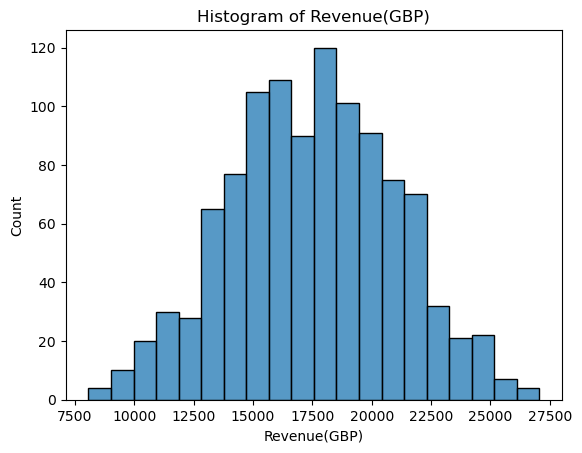

In [43]:
# histogram of revenue_gbp 
sns.histplot(df_daily_finance.revenue_gbp)
plt.ylabel('Count')
plt.xlabel('Revenue(GBP)')
plt.title("Histogram of Revenue(GBP)")
plt.show()

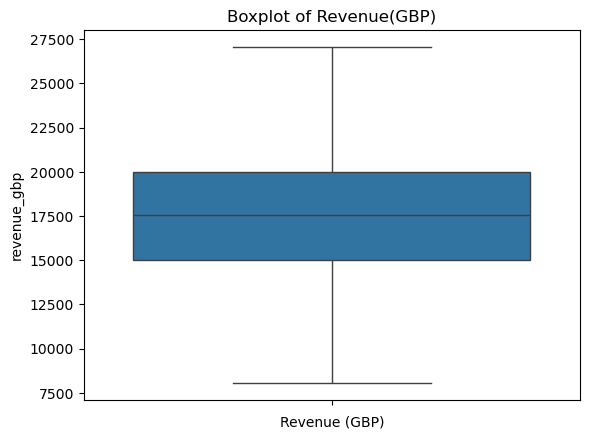

In [44]:
revenue = df_daily_finance.revenue_gbp.dropna()
q1,q3 = revenue.quantile([0.25,0.75])
median = revenue.median()

iqr = q3 - q1 
lower_bound = q1 - 1.5*iqr 
upper_bound = q3 + 1.5*iqr 
sns.boxplot(revenue,whis=1.5)
plt.xlabel('Revenue (GBP)')
plt.title("Boxplot of Revenue(GBP)")
plt.show()

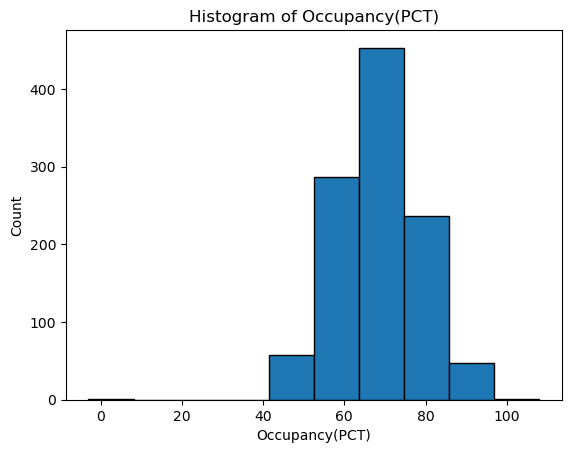

In [45]:
plt.hist(df_daily_finance.occupancy_pct, edgecolor='black' )
plt.xlabel("Occupancy(PCT)")
plt.ylabel("Count")
plt.title("Histogram of Occupancy(PCT)")
plt.show()

In [46]:
# Which missing values would you drop, fill, or leave alone?
## revenue_gbbp and operating_cost_gbp, I will fill them it is only 0.1% missing values. But notes has 80.5% missing values I couldn't make anything, but leave alone.
# Which values are impossible?
## Impossible values where occupancy_pct < 0 or occupancy_pct > 100.
# Do you see revenue outliers?
## No.
#Does revenue look approximately symmetric or skewed?
## It looks approximately symmetric.
# What does the occupancy histogram tell you?
## The main oocupancy distribution looks concentrated in a reasonable range, but there are impossible extreme observations outside valid 0-100% range.

# Task 3: Clean daily_finance
Now clean the table based on what you diagnosed in Task 2.

Work on a copy so you can compare before vs after:

df_clean = df_daily_finance.copy()

### Part A — Remove duplicates

1. Count duplicates before cleaning.
2. Remove exact duplicate rows.
3. Confirm duplicates are now zero.
4. Print how many rows were removed.

### Part B — Handle missing numeric values

Focus on:

- revenue_gbp
- operating_cost_gbp

For this project, because the missing percentage is extremely small, drop rows where either of these is missing.

Then:

confirm those two columns have no missing values
print how many rows were removed

Leave notes alone.

### Part C — Invalid occupancy values

Find rows where:

occupancy_pct<0

or

occupancy_pct>100

For this task, remove those rows rather than clipping or imputing them.

Then verify:

df_clean["occupancy_pct"].min()
df_clean["occupancy_pct"].max()

Both should now be within:

0≤occupancy_pct≤100

### Part D — Compare before vs after

For both the original and cleaned dataframe, calculate:

- number of rows
- mean revenue
- median revenue
- revenue standard deviation
- mean occupancy
- occupancy standard deviation

Create a small comparison table.

Something like:
| Metric         | Before | After |
| -------------- | -----: | ----: |
| Rows           |      ? |     ? |
| Mean revenue   |      ? |     ? |
| Median revenue |      ? |     ? |
| Revenue std    |      ? |     ? |
| Mean occupancy |      ? |     ? |
| Occupancy std  |      ? |     ? |

### Part E — Visual comparison

Create:

1. revenue histogram before cleaning
2. revenue histogram after cleaning
3. occupancy histogram before cleaning
4. occupancy histogram after cleaning

Use the same bins/ranges where possible so the comparison is meaningful.

### Part F — Interpretation

Answer:

1. Did cleaning materially change mean/median revenue?
2. Did removing invalid occupancy values materially change occupancy mean/std?
3. Why is it useful to compare summary statistics before and after cleaning?
4. Did you remove enough rows that you should worry about biasing the dataset?


In [47]:
#Part A 
# Create copy of daily finance dataFrame 
df_clean = df_daily_finance.copy()

# Count the duplicates 
duplicates = df_clean.duplicated().sum()
print(f"Duplicates before cleaning are {duplicates}.")
rows_before = df_clean.shape[0]
# Remove the duplicates 
df_clean.drop_duplicates(inplace=True)
rows_after = df_clean.shape[0]
# Confirming the duplicates are zero.
print(f"Duplicates after cleaning are {df_clean.duplicated().sum()}")
#Printing how many rows were removed 
print(f"{rows_before-rows_after} rows were removed.")

Duplicates before cleaning are 2.
Duplicates after cleaning are 0
2 rows were removed.


In [48]:
#Part B
# Drop missing values in revenue and operating_cost 
rows_before = df_clean.shape[0]
# Droping missing values 
df_clean.dropna(inplace=True, subset=['revenue_gbp', 'operating_cost_gbp']) 
rows_after = df_clean.shape[0]
# Confirming there is NO missing values 
print(f"Check for missing values \n{df_clean.isna().sum()}")
print(f"{rows_before-rows_after} rows were removed.")
print("Column 'Notes' has been left unchanged.")

Check for missing values 
date                    0
hotel_id                0
revenue_gbp             0
room_revenue_gbp        0
food_revenue_gbp        0
operating_cost_gbp      0
occupancy_pct           0
rating                  0
notes                 867
dtype: int64
2 rows were removed.
Column 'Notes' has been left unchanged.


In [49]:
# Part C 
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
print(f"Rows where occupancy has invalid value: \n{df_clean[(df_clean['occupancy_pct'] < 0) | (df_clean['occupancy_pct'] > 100)]}")
rows_before = df_clean[(df_clean['occupancy_pct'] < 0) | (df_clean['occupancy_pct'] > 100)].shape[0]
# Removing those rows 
df_clean.drop(df_clean[(df_clean['occupancy_pct'] < 0) | (df_clean['occupancy_pct'] > 100)].index, inplace=True)
rows_after = df_clean[(df_clean['occupancy_pct'] < 0) | (df_clean['occupancy_pct'] > 100)].shape[0]
#Check for new min value 
print(f"The new min value is {df_clean.occupancy_pct.min()}")
#Check for new max value 
print(f"The new max value is {df_clean.occupancy_pct.max()}")
print(f"{rows_before-rows_after} rows were removed.")

Rows where occupancy has invalid value: 
          date  hotel_id  revenue_gbp  room_revenue_gbp  food_revenue_gbp  operating_cost_gbp  occupancy_pct  rating notes
444 2026-03-16       101     16225.44          12069.75           4155.68            12558.43          108.0    4.17   NaN
777 2026-05-10       104     14578.18          11147.64           3430.54            11021.53           -3.0    4.31   NaN
The new min value is 41.8
The new max value is 96.3
2 rows were removed.


In [50]:
# Part D 

print(f'''
| Metric         | Before | After |
| -------------- | -----: | ----: |
| Rows           |   {df_daily_finance.shape[0]} |  {df_clean.shape[0]} |
| Mean revenue   |{df_daily_finance.revenue_gbp.mean().round(2)}|{df_clean.revenue_gbp.mean().round(2)}|
| Median revenue |{df_daily_finance.revenue_gbp.median()}|{df_clean.revenue_gbp.median():.2f}|
| Revenue std    |{df_daily_finance.revenue_gbp.std():.2f} | {df_clean.revenue_gbp.std():.2f}| 
| Mean occupancy |  {df_daily_finance.occupancy_pct.mean().round(2)} |  {df_clean.occupancy_pct.mean().round(2)} |
| Occupancy std  |  {df_daily_finance.occupancy_pct.std():.2f} |  {df_clean.occupancy_pct.std():.2f} |
''')


| Metric         | Before | After |
| -------------- | -----: | ----: |
| Rows           |   1082 |  1076 |
| Mean revenue   |17509.54|17507.51|
| Median revenue |17576.56|17578.08|
| Revenue std    |3501.22 | 3499.83| 
| Mean occupancy |  68.24 |  68.27 |
| Occupancy std  |  10.18 |  9.86 |



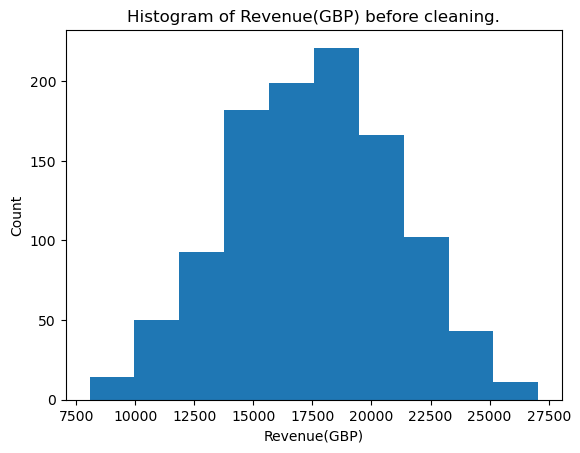

In [51]:
# Part E 
plt.hist(df_daily_finance.revenue_gbp, bins=10)
plt.xlim((df_daily_finance.revenue_gbp.min()-1000,df_daily_finance.revenue_gbp.max()+1000))
plt.title('Histogram of Revenue(GBP) before cleaning.')
plt.xlabel('Revenue(GBP)')
plt.ylabel('Count')
plt.show()

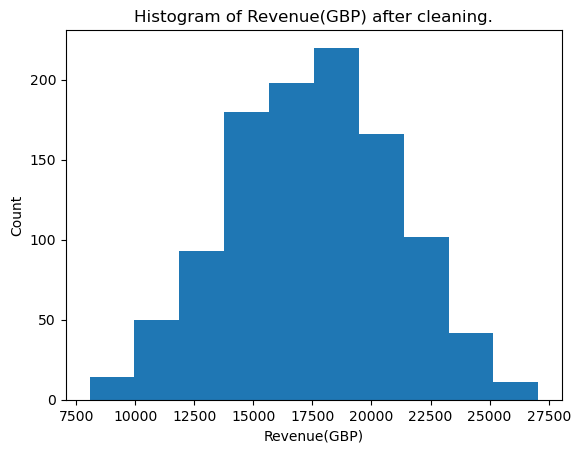

In [52]:
plt.hist(df_clean.revenue_gbp, bins=10)
plt.xlim((df_daily_finance.revenue_gbp.min()-1000,df_daily_finance.revenue_gbp.max()+1000))
plt.title('Histogram of Revenue(GBP) after cleaning.')
plt.xlabel('Revenue(GBP)')
plt.ylabel('Count')
plt.show()

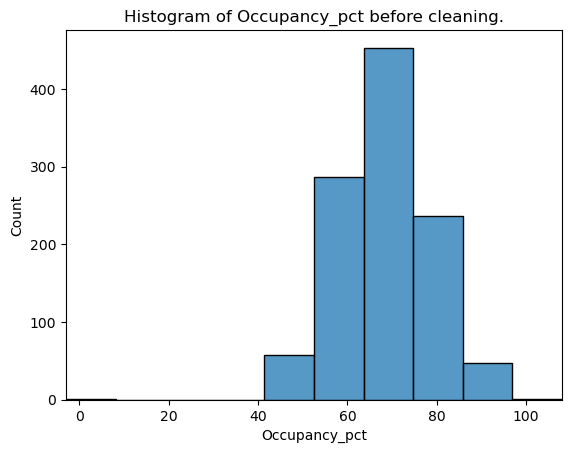

In [53]:
sns.histplot(df_daily_finance.occupancy_pct,bins=10)
plt.xlim((df_daily_finance.occupancy_pct.min(),df_daily_finance.occupancy_pct.max()))
plt.title('Histogram of Occupancy_pct before cleaning.')
plt.xlabel('Occupancy_pct')
plt.ylabel('Count')
plt.show()

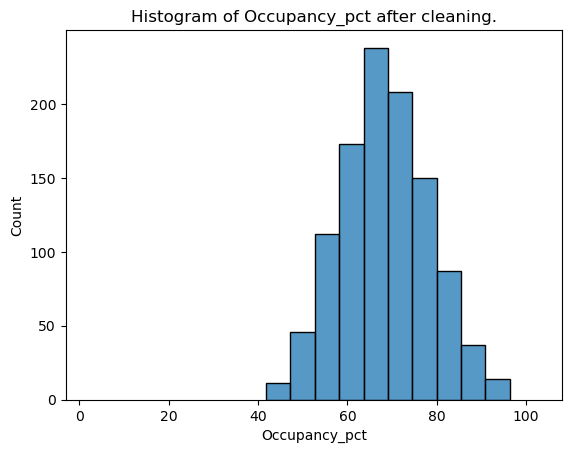

In [54]:
sns.histplot(df_clean.occupancy_pct, bins=10)
plt.xlim((df_daily_finance.occupancy_pct.min(),df_daily_finance.occupancy_pct.max()))
plt.title('Histogram of Occupancy_pct after cleaning.')
plt.xlabel('Occupancy_pct')
plt.ylabel('Count')
plt.show()

In [55]:
# Part F 
print("1. Cleaning changed insignificant mean/median of revenue.")
print("2. Cleaning didn't changed materially occupancy value of mean/std.")
print("3. We compare summary statistic before and after cleaning to verify that cleaning did not accidentally alter the dataset too much.")
print("4. I didn't remove enough rows to worry about baising the dataset.")

1. Cleaning changed insignificant mean/median of revenue.
2. Cleaning didn't changed materially occupancy value of mean/std.
3. We compare summary statistic before and after cleaning to verify that cleaning did not accidentally alter the dataset too much.
4. I didn't remove enough rows to worry about baising the dataset.


# Task 4 — Hotel-level descriptive analysis + visualizations

Now move from cleaning into actual analysis.

Using df_clean and df_hotels:

1. Merge them using hotel_id.
2. Verify:
- row count before merge
- row count after merge
- whether any hotel names are missing after the merge

3. For every hotel calculate:
- mean revenue
- median revenue
- revenue standard deviation
- mean occupancy
- occupancy standard deviation
- mean rating

4. Create these visualizations:
- bar chart: mean revenue by hotel
- bar chart: mean occupancy by hotel
- boxplot: revenue distribution by hotel
- line chart: daily revenue over time for one hotel of your choice

5. Answer:
   - Which hotel has the highest average revenue?
   - Which hotel has the most variable revenue?
   - Which hotel has the highest average occupancy?
   - Does the hotel with the highest revenue also have the highest occupancy?
   - From the boxplots, which hotel appears most consistent?
   - For your line chart, do you notice trend, seasonality, unusual peaks, or drops?

In [56]:
# Verify columns before and after merge 
before = (df_clean.shape[0],df_hotels.shape[0])
print(f"Rows before merging {before[0]}")
df_hotels_clean = pd.merge(left=df_clean, right=df_hotels, on='hotel_id')
print(f"Rows after merging {df_hotels_clean.shape[0]}")
df_hotels[df_hotels['hotel_name'].isin(df_hotels_clean['hotel_name'])]
print("All hotel names are involve after the merge.")

Rows before merging 1076
Rows after merging 1076
All hotel names are involve after the merge.


In [57]:
# mean revenue, occupancy and rating for each hotel
mean_revenue_occupancy_rating = df_hotels_clean.groupby('hotel_name')[['revenue_gbp','occupancy_pct', 'rating']].mean().reset_index()
mean_revenue_occupancy_rating

,hotel_name,revenue_gbp,occupancy_pct,rating
0,Bansko Mountain,16184.612333,63.188333,4.256667
1,Burgas Marina,16870.525611,65.600556,4.386278
2,Plovdiv Old Town,13245.029661,63.119209,4.284633
3,Sofia Airport,21332.717556,77.893889,4.320667
4,Sofia Central,19074.117207,71.331844,4.192905
5,Varna Sea View,18275.699000,68.444444,4.397444


In [58]:
#Standard deviation of revenue and occupancy for each hotel
std_revenue_occupancy = df_hotels_clean.groupby('hotel_name')[['revenue_gbp', 'occupancy_pct']].std().reset_index()
std_revenue_occupancy

,hotel_name,revenue_gbp,occupancy_pct
0,Bansko Mountain,2468.994931,8.393269
1,Burgas Marina,2494.143993,8.213890
2,Plovdiv Old Town,2137.822144,8.595114
3,Sofia Airport,2503.502436,8.382891
4,Sofia Central,2629.762295,8.408352
5,Varna Sea View,2389.765016,8.437143


In [59]:
# Median revenue for each hotel
median_revenue_hotels = df_hotels_clean.groupby('hotel_name')['revenue_gbp'].median()
median_revenue_hotels

hotel_name
Bansko Mountain     16348.550
Burgas Marina       16788.055
Plovdiv Old Town    13347.600
Sofia Airport       21492.795
Sofia Central       19020.140
Varna Sea View      18160.945
Name: revenue_gbp, dtype: float64

In [60]:
hotel_summary = (
    df_hotels_clean.groupby('hotel_name')
        .agg(
        mean_revenue=("revenue_gbp", "mean"),
        median_revenue=('revenue_gbp', 'median'),
        std_revenue=('revenue_gbp', 'std'),
        mean_occupancy=('occupancy_pct', 'mean'),
        std_occupancy=('occupancy_pct', 'std'),
        mean_rating=('rating', 'mean')
    )
    .reset_index()
)

hotel_summary

,hotel_name,mean_revenue,median_revenue,std_revenue,mean_occupancy,std_occupancy,mean_rating
0,Bansko Mountain,16184.612333,16348.550,2468.994931,63.188333,8.393269,4.256667
1,Burgas Marina,16870.525611,16788.055,2494.143993,65.600556,8.213890,4.386278
2,Plovdiv Old Town,13245.029661,13347.600,2137.822144,63.119209,8.595114,4.284633
3,Sofia Airport,21332.717556,21492.795,2503.502436,77.893889,8.382891,4.320667
4,Sofia Central,19074.117207,19020.140,2629.762295,71.331844,8.408352,4.192905
5,Varna Sea View,18275.699000,18160.945,2389.765016,68.444444,8.437143,4.397444


In [61]:
top_revenue = hotel_summary.loc[hotel_summary["mean_revenue"].idxmax()]
top_std = hotel_summary.loc[hotel_summary["std_revenue"].idxmax()]
top_occupancy = hotel_summary.loc[hotel_summary["mean_occupancy"].idxmax()]

print(
    f"Highest mean revenue: {top_revenue['hotel_name']} "
    f"({top_revenue['mean_revenue']:.2f})"
)

print(
    f"Largest revenue std: {top_std['hotel_name']} "
    f"({top_std['std_revenue']:.2f})"
)

print(
    f"Highest mean occupancy: {top_occupancy['hotel_name']} "
    f"({top_occupancy['mean_occupancy']:.2f}%)"
)

Highest mean revenue: Sofia Airport (21332.72)
Largest revenue std: Sofia Central (2629.76)
Highest mean occupancy: Sofia Airport (77.89%)


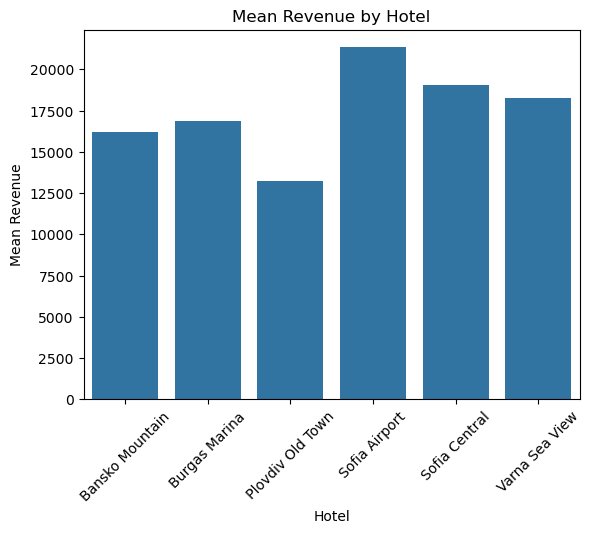

In [62]:
#part Visualizations 
# barchart of mean revenue by hotel
sns.barplot(x=hotel_summary['hotel_name'], y = hotel_summary['mean_revenue'])
plt.xticks(rotation=45)
plt.xlabel('Hotel')
plt.ylabel('Mean Revenue')
plt.title('Mean Revenue by Hotel')
plt.show()

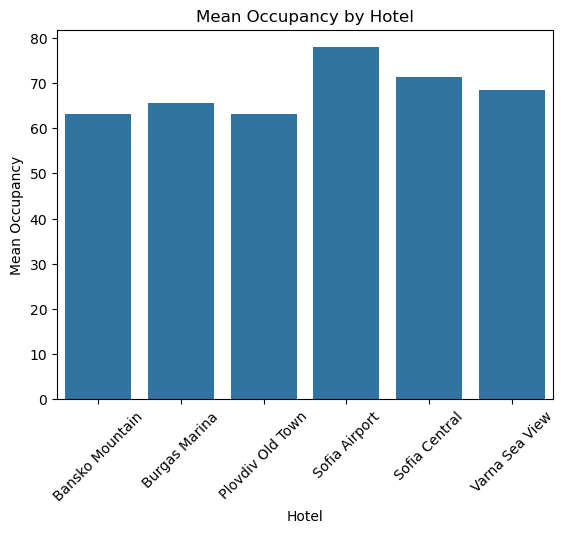

In [63]:
#bar chart of mean occupancy by hotel 
sns.barplot(data=hotel_summary,x='hotel_name', y='mean_occupancy')
plt.xticks(rotation=45)
plt.xlabel('Hotel')
plt.ylabel('Mean Occupancy')
plt.title('Mean Occupancy by Hotel')
plt.show()

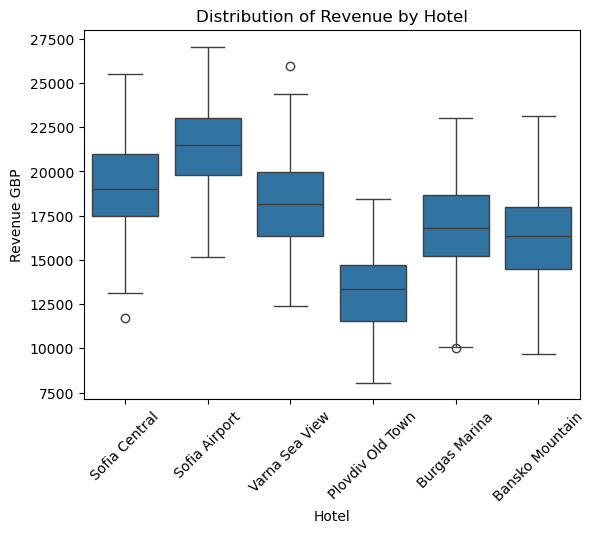

In [64]:
# boxplot of revenue distribution by hotel 
sns.boxplot(data=df_hotels_clean,x='hotel_name',y="revenue_gbp")
plt.xticks(rotation=45)
plt.xlabel('Hotel')
plt.ylabel('Revenue GBP')
plt.title("Distribution of Revenue by Hotel") 
plt.show()

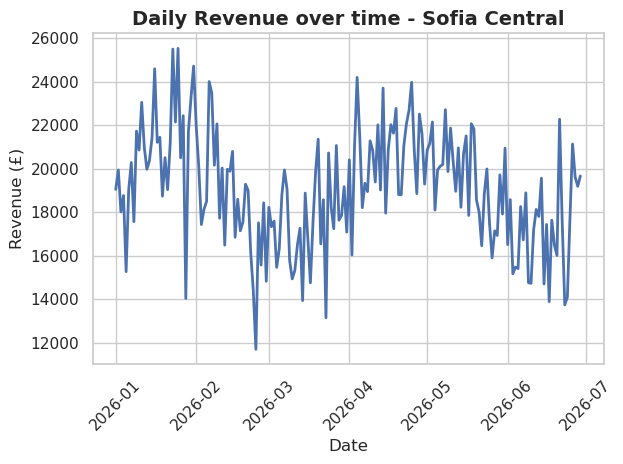

In [65]:
sns.set_theme(style='whitegrid')
sns.lineplot(data=df_hotels_clean[df_hotels_clean['hotel_name']=='Sofia Central'].sort_values('date'), x='date', y='revenue_gbp',errorbar=None,linewidth=2)
plt.title(
    'Daily Revenue over time - Sofia Central', fontsize=14, fontweight='bold'
)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [66]:
max_mean_revenue = hotel_summary.loc[hotel_summary.mean_revenue.idxmax(),['hotel_name', 'mean_revenue']]
print(f"Hotel: {max_mean_revenue.hotel_name} has highest mean revenue {max_mean_revenue.mean_revenue}.")
most_variable_revenue = hotel_summary.loc[hotel_summary.std_revenue.idxmax(),['hotel_name', 'std_revenue']]
print(f'Hotel with most variable revenue is {most_variable_revenue.hotel_name} with standard deviation {most_variable_revenue.std_revenue}.')
highest_average_occupancy = hotel_summary.loc[hotel_summary['mean_occupancy'].idxmax(),['hotel_name', 'mean_occupancy']]
print(f"Hotel with most average occupancy is {highest_average_occupancy.hotel_name} with average occupancy {highest_average_occupancy.mean_occupancy}.")
print("Hotel with highest mean revenue is the same hotel with highest average occupancy.")
print("As I look at the boxplot, I will say Plovdiv old town, because whiskers are the narrowest.")
print(f"The series shows an overall downward trend with a repeating pattern that may indicate seasonality,plus several unusual peaks followed by sharp drops.")

Hotel: Sofia Airport has highest mean revenue 21332.717555555555.
Hotel with most variable revenue is Sofia Central with standard deviation 2629.7622950208847.
Hotel with most average occupancy is Sofia Airport with average occupancy 77.89388888888888.
Hotel with highest mean revenue is the same hotel with highest average occupancy.
As I look at the boxplot, I will say Plovdiv old town, because whiskers are the narrowest.
The series shows an overall downward trend with a repeating pattern that may indicate seasonality,plus several unusual peaks followed by sharp drops.


# Feature Engineering and Grouped Analysis
Use your cleaned dataframe: df_clean

The goal is to create useful analytical features from the existing columns and then compare hotel performance.

### Part A — Check and prepare dates

Inspect the datatype of: date

If necessary, convert it to a pandas datetime datatype.

Then create these new columns from date:

- year
- month
- month_name
- day_of_week

After creating them, print the first 10 rows containing:

- date
- year
- month
- month_name
- day_of_week

Answer:

1. Why is datetime preferable to keeping dates as strings?
2. Which of the new columns are categorical and which are numerical?

### Part B — Create financial features

Create:Profit

profit=revenue−operating cost

profit_gbp

Profit margin: 

profit margin=(profit/revenue) × 100

New column:

profit_margin_pct


Then inspect:

- minimum profit
- maximum profit
- mean profit
- median profit
- mean profit margin

Also count how many rows have:

$$ profit < 0 $$

These represent loss-making hotel-days.

### Part C — Hotel-level aggregation

Group the cleaned data by:

hotel_id

Calculate for each hotel:

- total revenue
- average revenue
- total operating cost
- total profit
- average profit
- average occupancy
- average rating

Create one aggregated dataframe.

Try to give the columns clear names instead of leaving them as confusing multi-level column names.

Then answer:

1. Which hotel_id has the highest total profit?
2. Which has the lowest total profit?
3. Which has the highest average occupancy?
4. Does the hotel with the highest revenue also have the highest profit?

### Part D — Profitability vs occupancy

Investigate whether hotels with higher occupancy also tend to generate higher profit.

Create a scatter plot using the hotel-level aggregated dataframe:

- x-axis: average occupancy
- y-axis: average profit

Then calculate the correlation between those two variables.

Answer:

1. Is the relationship positive or negative?
2. Is it weak, moderate, or strong?
3. Does correlation prove that higher occupancy causes higher profit?

### Part E — Day-of-week analysis

Group by:

day_of_week

Calculate:

- average revenue
- average profit
- average occupancy

The weekdays should appear in logical order:

Monday
Tuesday
Wednesday
Thursday
Friday
Saturday
Sunday

Create one visualization showing average revenue by day of week.

Then answer:

1. Which day has the highest average revenue?
2. Which has the lowest?
3. Which day has the highest average occupancy?
4. Do revenue and occupancy appear to follow a similar weekly pattern?

### Part F — Interpretation

Write a short analytical summary answering:

1. Which hotel appears strongest financially?
2. Are there many loss-making days?
3. Is occupancy strongly related to profit?
4. Is there a noticeable weekday/weekend revenue pattern?
5. Which new engineered feature was most useful: profit_gbp, profit_margin_pct, or the date features? Why?

In [67]:
# Part A 
#creating a year column
df_clean['year'] = df_clean.date.dt.year
#creating a month column
df_clean['month'] = df_clean.date.dt.month
#creating a month_name column
# pd.to_datetime(df_clean['date'], format='%m').dt.strftime('%B')
df_clean['month_name'] = df_clean.date.dt.strftime('%B')
#creating day_of_week column 
#df_clean.date.dt.strftime('%A')
df_clean['day_of_week'] = df_clean.date.dt.day_name()
df_clean.day_of_week = df_clean.day_of_week.astype('category')
df_clean[['date','year','month','month_name','day_of_week']].head(10)
print("Datetime is better than strings because pandas can directly extract time components,sort chronologically, filter date range, resample and calculate time differences.")
print("Year and month are numerical, month_name and day_of_week are categorical.")

Datetime is better than strings because pandas can directly extract time components,sort chronologically, filter date range, resample and calculate time differences.
Year and month are numerical, month_name and day_of_week are categorical.


In [68]:
#Part B
df_clean['profit_gbp'] = df_clean.revenue_gbp-df_clean.operating_cost_gbp
df_clean['profit_margin_pct'] = df_clean.profit_gbp/df_clean.revenue_gbp*100
minimum_profit = df_clean['profit_gbp'].min()
max_profit = df_clean['profit_gbp'].max()
print(f"Min profit is {minimum_profit} and max profit is {max_profit}.")
mean_profit = df_clean.profit_gbp.mean()
median_profit = df_clean.profit_gbp.median()
mean_profit_margin = df_clean.profit_margin_pct.mean()
print(f"Mean profit is {mean_profit}, median profit is {median_profit}, mean profit margin is {mean_profit_margin}.")
number_rows_profit_less_0 = df_clean[df_clean['profit_gbp']<0].shape[0]
# (df_clean['profit_gbp']<0).sum()
print(f"Number of rows, where profit is less than 0 is: {number_rows_profit_less_0}")
loss_pct = (df_clean['profit_gbp']<0).mean() * 100

Min profit is 1591.7999999999993 and max profit is 8405.710000000003.
Mean profit is 4380.178661710037, median profit is 4281.070000000001, mean profit margin is 25.025626054579664.
Number of rows, where profit is less than 0 is: 0


In [93]:
# Part C 
hotels_info = (df_clean.groupby('hotel_id').agg(
    total_revenue = ('revenue_gbp', 'sum'),
    average_revenue = ('revenue_gbp', 'mean'),
    total_operating_cost =('operating_cost_gbp', 'sum'),
    total_profit = ('profit_gbp', 'sum'),
    average_profit=('profit_gbp','mean'),
    average_occupancy=('occupancy_pct', 'mean'),
    average_rating=('rating', 'mean')
    )
.reset_index()
)
#hotel_id with highest total profit 
highest_profit = hotels_info.loc[hotels_info['total_profit'].idxmax(),['hotel_id','total_profit']]
print(f"Hotel with id {highest_profit['hotel_id']:.0f} has the highest total profit {highest_profit['total_profit']}")
lowest_profit = hotels_info.loc[hotels_info['total_profit'].idxmin(), ['hotel_id', 'total_profit']]
print(f"Hotel with id {lowest_profit['hotel_id']:.0f} has the lowest total profit {lowest_profit['total_profit']}")
highest_average_occupancy = hotels_info.loc[hotels_info['average_occupancy'].idxmax(),['hotel_id','average_occupancy']]
print(f"Hotel with id {highest_average_occupancy['hotel_id']:.0f} has the highest average occupancy {highest_average_occupancy['average_occupancy']}")
highest_total_revenue = hotels_info.loc[hotels_info.total_revenue.idxmax(),['hotel_id', 'total_revenue']]
print(f"Hotel with id {highest_total_revenue['hotel_id']} has highest total revenue, meanwhile it has as well the highest total profit .")

Hotel with id 102 has the highest total profit 970133.63
Hotel with id 104 has the lowest total profit 590848.7
Hotel with id 102 has the highest average occupancy 77.89388888888888
Hotel with id 102.0 has highest total revenue, meanwhile it has as well the highest total profit .


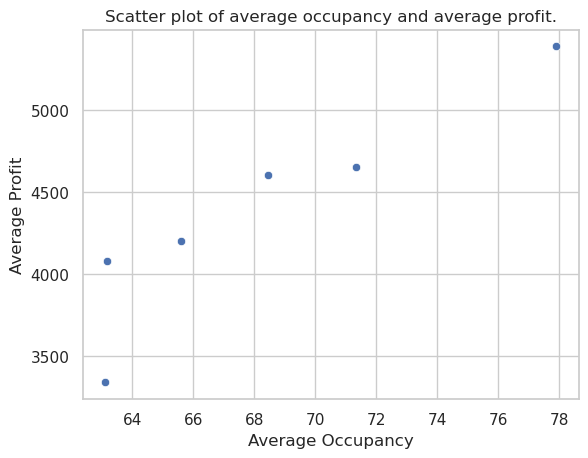

In [97]:
# part D 
sns.scatterplot(data=hotels_info,x='average_occupancy',y='average_profit',)
plt.xlabel('Average Occupancy')
plt.ylabel('Average Profit')
plt.title("Scatter plot of average occupancy and average profit.")
plt.show()

# $$ ∣r∣<0.3→weak $$
# $$ 0.3 \le |r| < 0.7 \rightarrow \text{moderate} $$
# $$ ∣r∣≥0.7→strong $$

In [102]:
correlation = hotels_info['average_occupancy'].corr(hotels_info.average_profit)
print(f'The correlation between average occupancy and average profit is {correlation}.They have strong positive correlation.')
print("The scatter plot visually support the correlation value.")
print('Correlation does NOT prove that higher average occupancy causes higher average profit. It only shows that there is a statistical relationship between them,\
increasing average occupancy is associated with increasing in average profit but it does not causes it. Other factors such as hotel size, room prices, operating costs, location, or seasonality may affect both variables.')

The correlation between average occupancy and average profit is 0.9216416294348616.They have strong positive correlation.
The scatter plot visually support the correlation value.
Correlation does NOT prove that higher average occupancy causes higher average profit. It only shows that there is a statistical relationship between them,increasing average occupancy is associated with increasing in average profit but it does not causes it. Other factors such as hotel size, room prices, operating costs, location, or seasonality may affect both variables.


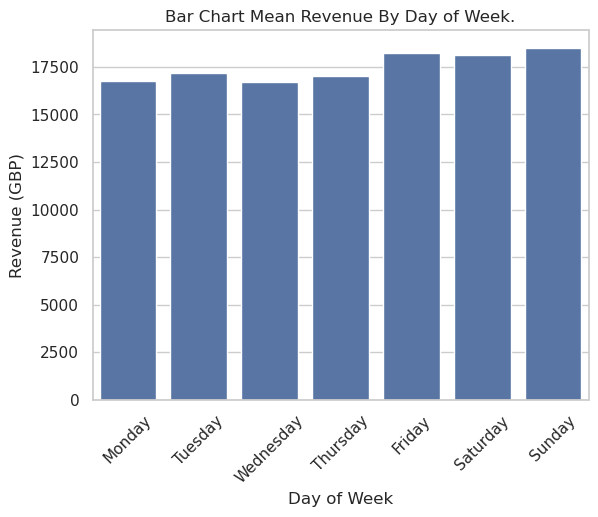

1. The Sunday has the highest mean revenue: 18499.86070967742.
2. The Wednesday has the lowest mean revenue: 16700.556999999997.
3. The Friday has the highest mean occupancy: 68.60064516129033.
4. The correlation between mean revenue and mean occupancy is 0.39.
It is moderately positive, so revenue and occupancy show a moderately similar weekly pattern.


In [182]:
# Part E 
day_of_week_summary=df_clean.groupby('day_of_week',observed=True)[['revenue_gbp','profit_gbp', 'occupancy_pct']].mean().reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_summary['day_of_week'] = pd.Categorical(day_of_week_summary['day_of_week'],categories=day_order, ordered=True)
day_of_week_summary = day_of_week_summary.sort_values('day_of_week').reset_index(drop=True)
# Creating bar chart of mean revenue by day of week 
sns.barplot(data=day_of_week_summary, x='day_of_week', y='revenue_gbp')
plt.xticks(rotation=45)
plt.xlabel("Day of Week")
plt.ylabel('Revenue (GBP)')
plt.title('Bar Chart Mean Revenue By Day of Week.')
plt.show()
# Answers:
day_highest_mean_revenue = day_of_week_summary.loc[day_of_week_summary['revenue_gbp'].idxmax()]
print(f"1. The {day_highest_mean_revenue['day_of_week']} has the highest mean revenue: {day_highest_mean_revenue['revenue_gbp']}.")
day_lowest_mean_revenue = day_of_week_summary.loc[day_of_week_summary['revenue_gbp'].idxmin()]
print(f"2. The {day_lowest_mean_revenue['day_of_week']} has the lowest mean revenue: {day_lowest_mean_revenue['revenue_gbp']}.")
day_highest_occupancy = day_of_week_summary.loc[day_of_week_summary['occupancy_pct'].idxmax()]
print(f"3. The {day_highest_occupancy['day_of_week']} has the highest mean occupancy: {day_highest_occupancy['occupancy_pct']}.")
correlation = day_of_week_summary['revenue_gbp'].corr(day_of_week_summary['occupancy_pct'])
print(f"4. The correlation between mean revenue and mean occupancy is {correlation:.2f}.\n\
It is moderately positive, so revenue and occupancy show a moderately similar weekly pattern.")

In [191]:
# Part F 
print('1. Hotel with id 102 appears financially strongest.')
print('2. There is 0 loss-making days.')
print('3. Average occupancy and average profit have a strong positive correlation.')
print('4. There is a visible weekly pattern, with average weened revenue higher than weekday revenue.')
print('5. date features are most useful engineered features, because they enabled additional time-based analysis by weekday and month.')


1. Hotel with id 102 appears financially strongest.
2. There is 0 loss-making days.
3. Average occupancy and average profit have a strong positive correlation.
4. There is a visible weekly pattern, with average weened revenue higher than weekday revenue.
5. date features are most useful engineered features, because they enabled additional time-based analysis by weekday and month.


# Task 5 — Merge Financial Data with Hotel Information

Merge df_clean with df_hotels on: hotel_id 

Store the result as: df_merged

Then check:

- rows before merge
-  rows after merge
-  columns before/after
-  missing hotel_name values after merge

Answer:

1. Did the number of rows change?
2. If rows increased unexpectedly, what could that indicate?
3. Why is validate= useful in merge()?

# Part B — Analyze by hotel category

Group by: category_rooms

Calculate:

- mean revenue
- total revenue
- mean profit
- total profit
- mean occupancy

Then answer:

4. Which category has the highest mean revenue?
5. Which has the highest total profit?
6. Which has the highest mean occupancy?
7. Does the category with the highest revenue also have the highest profit?

### Part C — Analyze by hotel

Using the merged dataframe, group by: hotel_name

Calculate:

- total revenue
- total profit
- mean revenue
- mean profit
- mean occupancy

Then identify the strongest hotel financially.

### Part D — Visualization

Create:

- bar chart of mean revenue by hotel category
- bar chart of total profit by hotel

### Part E — Interpretation

Explain:

1. Which hotel category appears strongest?
2. Which hotel appears strongest?
3. What extra insight did the merge give you compared with df_clean alone?
4. Why are lookup tables useful in EDA?


Before the merge there is 1076 rows and 15 columns.
After the merge there is 1076 rows and 21 columns. There is 0 missing values in hotel name column.
The number of rows after merged have not been changed.
If rows increased unexpectedly, that will indicated df_hotels contains duplicated hotel_id values.
df_clean contains many rows for same hotel id, df_hotels contains only one row per hotel id.

1. Category Business has the highest mean revenue with 20206.56
2. Category Resort has the highest total profit with 2319326.85
3. Category Business has the highest mean occupancy with 74.62
4. No. Business has the highest mean revenue, while Resort has the highest total profit.

1. Hotel Sofia Airport has the highest total revenue 3839889.16.
2. Hotel Sofia Airport has the highest total profit 970133.63.
3. Hotel Sofia Airport has the highest mean revenue 21332.72.
4. Hotel Sofia Airport has the highest mean occupancy 77.89.
5. Yes. Sofia Airport has both the highest total revenue and the high

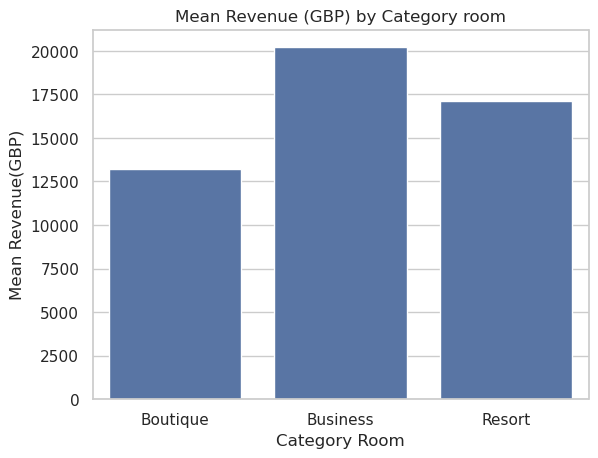

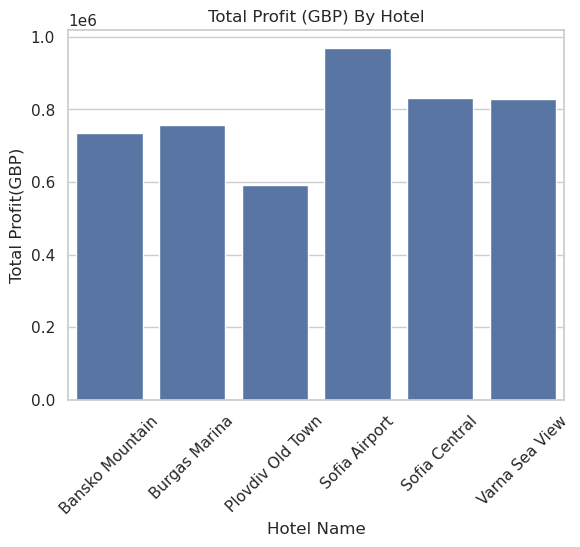


1. Bussines category appears strongest overall.
2. Sofia Airport appears strongest overall.
3. The merge provide us additional hotel-based analyses by hotel_name, category room and etc.
4. Lookup tables contians attribute information about entities and allow us to group data by this attributes and analyse the results.


In [289]:
# Part A
before= df_clean.shape
df_merged = df_clean.merge(df_hotels, on='hotel_id',how='left',validate='many_to_one')
after = df_merged.shape
missing_hotel_name = df_merged.hotel_name.isna().sum()
print(f"Before the merge there is {before[0]} rows and {before[1]} columns.")
print(f"After the merge there is {after[0]} rows and {after[1]} columns. There is {missing_hotel_name} missing values in hotel name column.")
print('The number of rows after merged have not been changed.')
print('If rows increased unexpectedly, that will indicated df_hotels contains duplicated hotel_id values.')
print("df_clean contains many rows for same hotel id, df_hotels contains only one row per hotel id.")
print()
# Part B 
df_category_room = df_merged.groupby('category')[['revenue_gbp', 'profit_gbp', 'occupancy_pct']].agg(
    mean_revenue=('revenue_gbp','mean'),
    total_revenue=('revenue_gbp', 'sum'),
    mean_profit=('profit_gbp', 'mean'),
    total_profit=('profit_gbp', 'sum'),
    mean_occupancy=('occupancy_pct', 'mean')
).reset_index()
print(f"1. Category {df_category_room.loc[df_category_room['mean_revenue'].idxmax()]['category']} has the highest mean revenue with {df_category_room.loc[df_category_room['mean_revenue'].idxmax()]['mean_revenue']:.2f}")
print(f"2. Category {df_category_room.loc[df_category_room['total_profit'].idxmax()]['category']} has the highest total profit with {df_category_room.loc[df_category_room['total_profit'].idxmax()]['total_profit']:.2f}")
print(f"3. Category {df_category_room.loc[df_category_room['mean_occupancy'].idxmax()]['category']} has the highest mean occupancy with {df_category_room.loc[df_category_room['mean_occupancy'].idxmax()]['mean_occupancy']:.2f}")
highest_mean_revenue_category = df_category_room.loc[
    df_category_room['mean_revenue'].idxmax(),
    'category'
]

highest_total_profit_category = df_category_room.loc[
    df_category_room['total_profit'].idxmax(),
    'category'
]

if highest_mean_revenue_category == highest_total_profit_category:
    print(
        f"4. Yes. {highest_mean_revenue_category} has both the highest "
        "mean revenue and the highest total profit."
    )
else:
    print(
        f"4. No. {highest_mean_revenue_category} has the highest mean revenue, "
        f"while {highest_total_profit_category} has the highest total profit."
    )
print()
# Part C
df_hotel_name = df_merged.groupby('hotel_name')[['revenue_gbp','profit_gbp','occupancy_pct']].agg(
    total_revenue = ('revenue_gbp', 'sum'),
    total_profit = ('profit_gbp', 'sum'),
    mean_revenue = ('revenue_gbp', 'mean'),
    mean_profit = ('profit_gbp', 'mean'),
    mean_occupancy = ('occupancy_pct', 'mean')
).reset_index()

hotel_highest_total_revenue = df_hotel_name.loc[df_hotel_name['total_revenue'].idxmax(),'hotel_name']
hotel_highest_total_profit = df_hotel_name.loc[df_hotel_name['total_profit'].idxmax(),'hotel_name']
print(f"1. Hotel {df_hotel_name.loc[df_hotel_name['total_revenue'].idxmax()]['hotel_name']} has the highest total revenue {df_hotel_name.loc[df_hotel_name['total_revenue'].idxmax()]['total_revenue']:.2f}.")
print(f"2. Hotel {df_hotel_name.loc[df_hotel_name['total_profit'].idxmax()]['hotel_name']} has the highest total profit {df_hotel_name.loc[df_hotel_name['total_profit'].idxmax()]['total_profit']:.2f}.")
print(f"3. Hotel {df_hotel_name.loc[df_hotel_name['mean_revenue'].idxmax()]['hotel_name']} has the highest mean revenue {df_hotel_name.loc[df_hotel_name['mean_revenue'].idxmax()]['mean_revenue']:.2f}.")
print(f"4. Hotel {df_hotel_name.loc[df_hotel_name['mean_occupancy'].idxmax()]['hotel_name']} has the highest mean occupancy {df_hotel_name.loc[df_hotel_name['mean_occupancy'].idxmax()]['mean_occupancy']:.2f}.")

if hotel_highest_total_revenue == hotel_highest_total_profit:
    print(
        f"5. Yes. {hotel_highest_total_revenue} has both the highest "
        "total revenue and the highest total profit."
    )
else:
    print(
        f"5. No. {hotel_highest_total_revenue} has the highest total revenue, "
        f"while {hotel_highest_total_profit} has the highest total profit."
    )

print()
# Part D 
# creating bar chart of mean revenue by hotel category 
sns.barplot(data=df_category_room, x='category',y='mean_revenue')
plt.xlabel("Category Room")
plt.ylabel("Mean Revenue(GBP)")
plt.title("Mean Revenue (GBP) by Category room")
plt.show()

sns.barplot(data=df_hotel_name,x='hotel_name',y='total_profit')
plt.xlabel('Hotel Name')
plt.ylabel("Total Profit(GBP)")
plt.title("Total Profit (GBP) By Hotel")
plt.xticks(rotation=45)
plt.show()
print()
#Part F 
print("1. Bussines category appears strongest overall.")
print("2. Sofia Airport appears strongest overall.")
print("3. The merge provide us additional hotel-based analyses by hotel_name, category room and etc.")
print("4. Lookup tables contians attribute information about entities and allow us to group data by this attributes and analyse the results.")

In [284]:
df_category_room

,category,mean_revenue,total_revenue,mean_profit,total_profit,mean_occupancy
0,Boutique,13245.029661,2344370.25,3338.128249,590848.70,63.119209
1,Business,20206.563064,7254156.14,5021.996351,1802896.69,74.622006
2,Resort,17110.278981,9239550.65,4295.049722,2319326.85,65.744444
